In [1]:
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from utils import *
from genData import *
from plot import *
from model.unet import Attention_UNet

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. No GPU found.")

# Configuration
det = 'H1L1'
f0 = 20
size = (512, 64)
Tsft = 14400
train_level = 32
batch_size = 8

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed4.npz'
val_data = np.load(filename, allow_pickle=True)
targets = val_data['clean_image']
masks = new_mask(normalize(targets))  # Assuming new_mask and normalize are defined in utils

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)

25-08-09 01:08:32.341 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


GPU Name: Tesla V100-PCIE-16GB


<All keys matched successfully>

In [2]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Print the number of trainable parameters
print(f"Number of trainable parameters: {count_trainable_parameters(model)}")

Number of trainable parameters: 34879348


In [11]:
# Initialize lists for depth and pdet
depth = []
pdet = []
max_train_levels = [5*i for i in range(1, 21)]  
# Compute pdet
noise_data = np.empty((1000,) + size + (4,))
for i in range(noise_data.shape[0]):
    noise_data[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
noise_data = normalize(noise_data)
noise_loader = load_dataset(noise_data, batch_size=batch_size, shuffle=False)

noise_predictions = []
with torch.no_grad():
    for batch in tqdm(noise_loader, desc="Processing noise"):
        images = batch[0].to(device)
        outputs = model(images)
        noise_predictions.append(outputs.cpu().numpy())
noise_predictions = np.concatenate(noise_predictions, axis=0)
noise_stats = compute_detection_statistic(noise_predictions, method='mean_sq')

    
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    data = normalize(noise + targets)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth.append(Sn)
    pdet.append(pdet_value)

# Convert to numpy arrays
depth = np.array(depth)
pdet = np.array(pdet)

Processing Sn=100: 100%|██████████| 125/125 [00:04<00:00, 25.57it/s]


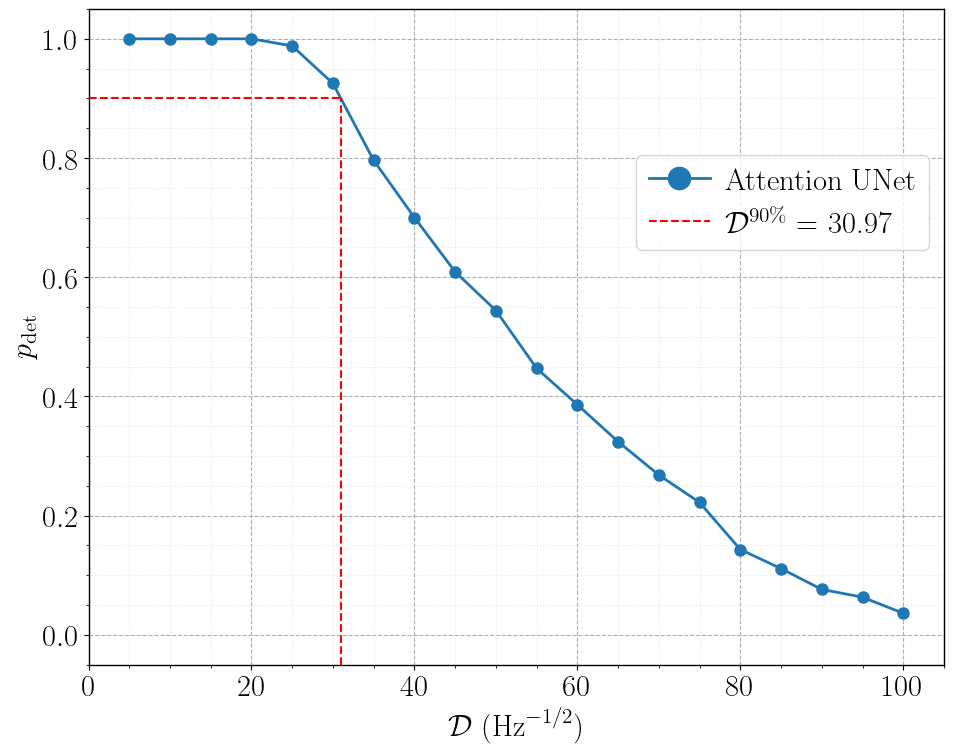

In [12]:
# Data from previous context (assuming depth and pdet are from the optimized code)
depth_mf = np.array([20.202557445466237, 29.819911193070148, 35.00972993958217, 
                     43.98243272753743, 55.55819765607939, 59.86577050930532, 
                     70.5983063596438, 79.96641836313785, 84.91922451653605, 
                     93.97578433989275, 100.0624074927814, 109.67219081357824])
pdet_mf = np.array([0.9968030411616241, 0.9972330414732185, 0.9664350481413393, 
                    0.8019879724550525, 0.5893621662044682, 0.5244757423737264, 
                    0.3989904340510392, 0.2883245567569252, 0.24539930826036832, 
                    0.16035272489327893, 0.11295921228928427, 0.05648583803321597])

            
# Create figure and axis
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # Use tab10 colormap for distinct colors

fig, ax = plt.subplots(figsize=(10, 8))

# Plot Weave data as a line
#ax.plot(depth_mf[:-2], pdet_mf[:-2], color='k', label='Weave', lw=2)
sort_idx = np.argsort(depth)
depth_sorted = depth[sort_idx]
pdet_sorted = pdet[sort_idx]
p90 = 0.9
d90 = np.interp(p90, pdet_sorted[::-1], depth_sorted[::-1])  # Reverse to handle decreasing pdet

# Plot Attention UNet data with line and markers
ax.plot(depth, pdet, color=colors[0], linestyle='-', lw=2, marker='o', markersize=8, label='Attention UNet')

# Add horizontal and vertical lines at pdet = 0.9 and interpolated depth
ax.plot([0, d90], [p90, p90], color='red', linestyle='--', lw=1.5)
ax.plot([d90, d90], [-0.05, p90], color='red', linestyle='--', lw=1.5, 
        label=r'$\mathcal{D}^{90\%}=$' + f' {d90:.2f}')

# Axis labels and styling
ax.set_xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$')
ax.set_ylabel(r'$p_{\mathrm{det}}$')
ax.legend(fontsize=22, loc='upper right', markerscale=2, handlelength=2, handletextpad=0.5, bbox_to_anchor=(1, 0.8))
ax.grid(True, which='major', linestyle='dashed')
ax.set_xlim(0, 105)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

# Save figure
plt.tight_layout()
#plt.savefig(f'../result/plots/pdet_with_error_bars.pdf', dpi=300, bbox_inches='tight')

In [13]:
max_train_levels = [40.2790, 31]

depth_ex = []
pdet_ex = []
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    data = normalize(noise + targets)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth_ex.append(Sn)
    pdet_ex.append(pdet_value)

# Convert to numpy arrays
depth_ex = np.array(depth_ex)
pdet_ex = np.array(pdet_ex)

Processing Sn=31: 100%|██████████| 125/125 [00:04<00:00, 25.26it/s]


In [14]:
depth_ex, pdet_ex

(array([40.279, 31.   ]), array([0.697, 0.901]))

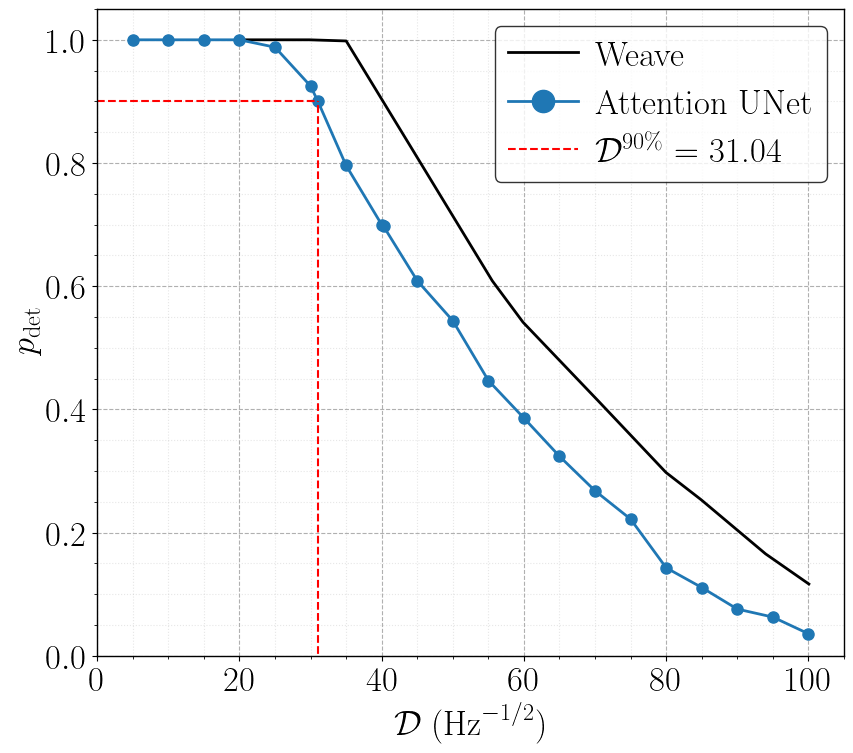

In [16]:
# Insert depth_ex and pdet_ex into depth and pdet to maintain ascending order
# Combine all points
combined = np.vstack((np.column_stack((depth, pdet)), np.column_stack((depth_ex, pdet_ex))))
# Sort by depth (first column)
sorted_indices = np.argsort(combined[:, 0])
depth_combined = combined[sorted_indices, 0]
pdet_combined = combined[sorted_indices, 1]

# Use only the first len(depth)-4 points from combined data (to match depth[:-4])
n_points = len(depth_combined)
depth_plot = depth_combined[:n_points]
pdet_plot = pdet_combined[:n_points]

# Interpolate depth at pdet = 0.9
# Sort by depth for interpolation (already sorted, but confirm)
sort_idx = np.argsort(depth_plot)
depth_sorted = depth_plot[sort_idx]
pdet_sorted = pdet_plot[sort_idx]

# Linear interpolation (reverse pdet to handle decreasing trend)
p90 = 0.9
d90 = np.interp(p90, pdet_sorted[::-1], depth_sorted[::-1])

# Create figure and axis
fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Data from previous context (assuming depth and pdet are from the optimized code)
depth_mf = np.array([20.202557445466237, 29.819911193070148, 35.00972993958217, 
                     43.98243272753743, 55.55819765607939, 59.86577050930532, 
                     70.5983063596438, 79.96641836313785, 84.91922451653605, 
                     93.97578433989275, 100.0624074927814, 109.67219081357824])
pdet_mf = np.array([0.9968030411616241, 0.9972330414732185, 0.9664350481413393, 
                    0.8019879724550525, 0.5893621662044682, 0.5244757423737264, 
                    0.3989904340510392, 0.2883245567569252, 0.24539930826036832, 
                    0.16035272489327893, 0.11295921228928427, 0.05648583803321597])

            
pdet_mf *= (921600/864000)**0.5
pdet_mf[pdet_mf>1] = 1
ax.plot(depth_mf[:-1], pdet_mf[:-1], color='k', label='Weave', lw=2)

# Plot combined Attention UNet data with line and markers
ax.plot(depth_plot, pdet_plot, color=colors[0], linestyle='-', lw=2, marker='o', markersize=8, label='Attention UNet')

# Add horizontal and vertical lines at pdet = 0.9 and interpolated depth
ax.plot([0, d90], [p90, p90], color='red', linestyle='--', lw=1.5)
ax.plot([d90, d90], [-0.05, p90], color='red', linestyle='--', lw=1.5, 
        label=r'$\mathcal{D}^{90\%}=$' + f' {d90:.2f}')

# Axis labels and styling
ax.set_xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$', fontsize=25)
ax.set_ylabel(r'$p_{\mathrm{det}}$', fontsize=25)
ax.legend(fontsize=25, loc=1, markerscale=2, handlelength=2, handletextpad=0.5, edgecolor='k')
ax.grid(True, which='major', linestyle='dashed')
ax.set_xlim(0, 105)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='both', which='major', labelsize=25)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

# Save figure
plt.tight_layout()
plt.savefig('../result/plots/pdet_20Hz.pdf', dpi=300, bbox_inches='tight')

In [2]:
model.eval()


# Compute pdet for noise-only data
noise_data = np.empty((1000,) + size + (4,))
for i in range(noise_data.shape[0]):
    noise_data[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
noise_data = apply_duty_factor(noise_data, duty_factor, size)  # Apply duty factor
noise_data = normalize(noise_data)
noise_loader = load_dataset(noise_data, batch_size=batch_size, shuffle=False)

noise_predictions = []
with torch.no_grad():
    for batch in tqdm(noise_loader, desc="Processing noise"):
        images = batch[0].to(device)
        outputs = model(images)
        noise_predictions.append(outputs.cpu().numpy())
noise_predictions = np.concatenate(noise_predictions, axis=0)
noise_stats = compute_detection_statistic(noise_predictions, method='mean_sq')

# Initialize lists for depth and pdet
depth = []
pdet = []
max_train_levels = [5*i for i in range(1, 2)] # 21

# Process each noise level
for Sn in max_train_levels:
    # Generate noise and add to signal
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
    data = noise + targets
    data = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data = normalize(data)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    # Compute pdet
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth.append(Sn)
    pdet.append(pdet_value)

# Convert to numpy arrays
depth = np.array(depth)
pdet = np.array(pdet)

25-08-06 19:23:23.089 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


GPU Name: Tesla V100-PCIE-16GB


Processing Sn=5: 100%|██████████| 125/125 [00:05<00:00, 24.68it/s]


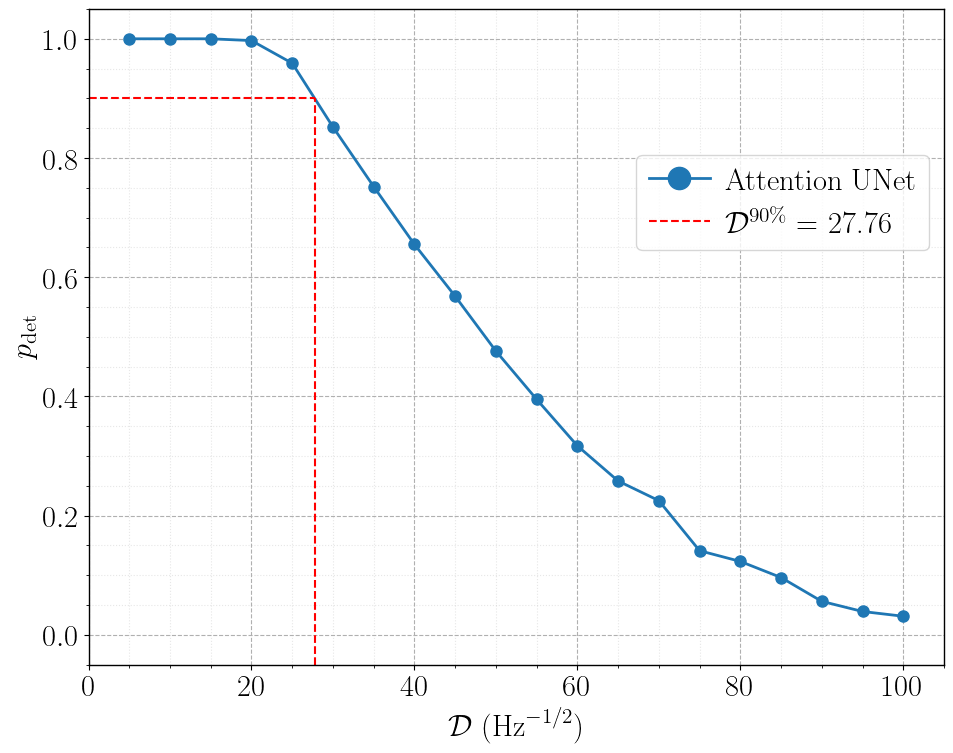

In [22]:
# Data from previous context (assuming depth and pdet are from the optimized code)
depth_mf = np.array([20.202557445466237, 29.819911193070148, 35.00972993958217, 
                     43.98243272753743, 55.55819765607939, 59.86577050930532, 
                     70.5983063596438, 79.96641836313785, 84.91922451653605, 
                     93.97578433989275, 100.0624074927814, 109.67219081357824])
pdet_mf = np.array([0.9968030411616241, 0.9972330414732185, 0.9664350481413393, 
                    0.8019879724550525, 0.5893621662044682, 0.5244757423737264, 
                    0.3989904340510392, 0.2883245567569252, 0.24539930826036832, 
                    0.16035272489327893, 0.11295921228928427, 0.05648583803321597])

            
# Create figure and axis
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # Use tab10 colormap for distinct colors

fig, ax = plt.subplots(figsize=(10, 8))

# Plot Weave data as a line
#ax.plot(depth_mf[:-2], pdet_mf[:-2], color='k', label='Weave', lw=2)
sort_idx = np.argsort(depth)
depth_sorted = depth[sort_idx]
pdet_sorted = pdet[sort_idx]
p90 = 0.9
d90 = np.interp(p90, pdet_sorted[::-1], depth_sorted[::-1])  # Reverse to handle decreasing pdet

# Plot Attention UNet data with line and markers
ax.plot(depth, pdet, color=colors[0], linestyle='-', lw=2, marker='o', markersize=8, label='Attention UNet')

# Add horizontal and vertical lines at pdet = 0.9 and interpolated depth
ax.plot([0, d90], [p90, p90], color='red', linestyle='--', lw=1.5)
ax.plot([d90, d90], [-0.05, p90], color='red', linestyle='--', lw=1.5, 
        label=r'$\mathcal{D}^{90\%}=$' + f' {d90:.2f}')

# Axis labels and styling
ax.set_xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$')
ax.set_ylabel(r'$p_{\mathrm{det}}$')
ax.legend(fontsize=22, loc='upper right', markerscale=2, handlelength=2, handletextpad=0.5, bbox_to_anchor=(1, 0.8))
ax.grid(True, which='major', linestyle='dashed')
ax.set_xlim(0, 105)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

# Save figure
plt.tight_layout()
#plt.savefig(f'../result/plots/pdet_with_error_bars.pdf', dpi=300, bbox_inches='tight')

In [23]:
max_train_levels = [27.5, 28, 28.5]

depth_ex = []
pdet_ex = []
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets
    data = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data = normalize(data)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)
    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth_ex.append(Sn)
    pdet_ex.append(pdet_value)

# Convert to numpy arrays
depth_ex = np.array(depth_ex)
pdet_ex = np.array(pdet_ex)

Processing Sn=28.5: 100%|██████████| 125/125 [00:05<00:00, 22.48it/s]


In [3]:
max_train_levels = [20]
duty_factor = 1.0 

# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets
    data = normalize(data)
    data = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions, inputs, ground_truth = [], [], []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
            
    predictions = np.concatenate(predictions, axis=0)

Processing Sn=20: 100%|██████████| 125/125 [00:05<00:00, 21.35it/s]


In [6]:
# Define duty factors to test
def compute_detection_statistic(images, method= 'mean'):
    valid_methods = {'mean', 'mean_sq', 'kl_one', 'kl_random'}
    if method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}, got {method}")

    images_np = np.abs(images)
                          
    if method == 'mean':
        return np.mean(images_np.transpose(0, 2, 3, 1), axis=(1, 2, 3))
    
    elif method == 'mean_sq':
        return np.mean(np.square(images_np.transpose(0, 2, 3, 1)), axis=(1, 2, 3))

# Load validation data
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed4.npz'
val_data = np.load(filename, allow_pickle=True)
targets = val_data['clean_image']
masks = new_mask(normalize(targets))

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)
model.eval()



duty_factors = [1.0, 0.9, 0.8, 0.7, 0.6]  # Range of duty factors (1.0 = no gaps, 0.4 = 60% gaps)

# Initialize results storage
results = {df: {'depth': [], 'pdet': []} for df in duty_factors}


# Process each duty factor
for duty_factor in duty_factors:
    
    if duty_factor == 0.7:
        max_train_levels = [d for d in range(23, 27)]  # Noise levels (5 to 100)
    elif duty_factor == 0.6:
        max_train_levels = [d for d in range(18, 22)]  # Noise levels (5 to 100)
    elif duty_factor >= 0.8:
        max_train_levels = [d for d in range(27, 33)]  # Noise levels (5 to 100)
        
    print(f"\nProcessing duty factor: {duty_factor}")
    num_zero_cols = int(size[1] * (1 - duty_factor))
    zero_cols = np.random.choice(size[1], size=num_zero_cols, replace=False)  # Randomly select columns
    
    # Compute noise statistics (no duty factor applied)
    noise_data = np.empty((1000,) + size + (4,))
    for i in range(noise_data.shape[0]):
        noise_data[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)

    noise_data = apply_duty_factor(noise_data, duty_factor, size, zero_cols)  # Apply duty factor
    noise_data = normalize(noise_data)
    noise_loader = load_dataset(noise_data, batch_size=batch_size, shuffle=False)
        
    noise_predictions = []
    with torch.no_grad():
        for batch in tqdm(noise_loader, desc="Processing noise"):
            images = batch[0].to(device)
            outputs = model(images)
            noise_predictions.append(outputs.cpu().numpy())
    noise_predictions = np.concatenate(noise_predictions, axis=0)
    noise_stats = compute_detection_statistic(noise_predictions, method='mean_sq')
    
    # Process each noise level
    for Sn in max_train_levels:
        # Generate noise and add to targets
        noise = np.empty((targets.shape[0],) + size + (4,))
        for i in range(noise.shape[0]):
            noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
        data = normalize(noise + targets)
        
        # Apply duty factor to data
        data = apply_duty_factor(data, duty_factor, size, zero_cols)
        
        data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

        # Compute predictions
        predictions = []
        with torch.no_grad():
            for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}, Duty={duty_factor}"):
                images = images.to(device)
                outputs = model(images)
                predictions.append(outputs.cpu().numpy())
        predictions = np.concatenate(predictions, axis=0)

        # Compute detection statistic
        stats = compute_detection_statistic(predictions, method='mean_sq')

        # Compute pdet
        x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
        mask = stats > x_pfa
        pdet_value = mask.sum() / mask.size

        # Store results
        results[duty_factor]['depth'].append(Sn)
        results[duty_factor]['pdet'].append(pdet_value)


Processing duty factor: 1.0


Processing Sn=32, Duty=1.0: 100%|██████████| 125/125 [00:05<00:00, 23.52it/s]



Processing duty factor: 0.9


Processing Sn=32, Duty=0.9: 100%|██████████| 125/125 [00:05<00:00, 24.54it/s]



Processing duty factor: 0.8


Processing Sn=32, Duty=0.8: 100%|██████████| 125/125 [00:05<00:00, 23.99it/s]



Processing duty factor: 0.7


Processing Sn=26, Duty=0.7: 100%|██████████| 125/125 [00:05<00:00, 23.90it/s]



Processing duty factor: 0.6


Processing Sn=21, Duty=0.6: 100%|██████████| 125/125 [00:05<00:00, 24.60it/s]


In [21]:
# Define duty factors to test
def compute_detection_statistic(images, method= 'mean'):
    valid_methods = {'mean', 'mean_sq', 'kl_one', 'kl_random'}
    if method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}, got {method}")

    images_np = np.abs(images)
                          
    if method == 'mean':
        return np.mean(images_np.transpose(0, 2, 3, 1), axis=(1, 2, 3))
    
    elif method == 'mean_sq':
        return np.mean(np.square(images_np.transpose(0, 2, 3, 1)), axis=(1, 2, 3))

# Load validation data
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed4.npz'
val_data = np.load(filename, allow_pickle=True)
targets = val_data['clean_image']
masks = new_mask(normalize(targets))

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)
model.eval()



duty_factors = [0.6]  # Range of duty factors (1.0 = no gaps, 0.4 = 60% gaps)

# Initialize results storage
results = {df: {'depth': [], 'pdet': []} for df in duty_factors}


# Process each duty factor
for duty_factor in duty_factors:
    
    if duty_factor == 0.7:
        max_train_levels = [d for d in range(23, 27)]  # Noise levels (5 to 100)
    elif duty_factor == 0.6:
        max_train_levels = [d for d in range(20, 24)]  # Noise levels (5 to 100)
    elif duty_factor >= 0.8:
        max_train_levels = [d for d in range(27, 33)]  # Noise levels (5 to 100)
        
    print(f"\nProcessing duty factor: {duty_factor}")
    num_zero_cols = int(size[1] * (1 - duty_factor))
    zero_cols = np.random.choice(size[1], size=num_zero_cols, replace=False)  # Randomly select columns
    
    # Compute noise statistics (no duty factor applied)
    noise_data = np.empty((1000,) + size + (4,))
    for i in range(noise_data.shape[0]):
        noise_data[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)

    noise_data = apply_duty_factor(noise_data, duty_factor, size, zero_cols)  # Apply duty factor
    noise_data = normalize(noise_data)
    noise_loader = load_dataset(noise_data, batch_size=batch_size, shuffle=False)
        
    noise_predictions = []
    with torch.no_grad():
        for batch in tqdm(noise_loader, desc="Processing noise"):
            images = batch[0].to(device)
            outputs = model(images)
            noise_predictions.append(outputs.cpu().numpy())
    noise_predictions = np.concatenate(noise_predictions, axis=0)
    noise_stats = compute_detection_statistic(noise_predictions, method='mean_sq')
    
    # Process each noise level
    for Sn in max_train_levels:
        # Generate noise and add to targets
        noise = np.empty((targets.shape[0],) + size + (4,))
        for i in range(noise.shape[0]):
            noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
        data = normalize(noise + targets)
        
        # Apply duty factor to data
        data = apply_duty_factor(data, duty_factor, size, zero_cols)
        
        data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

        # Compute predictions
        predictions = []
        with torch.no_grad():
            for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}, Duty={duty_factor}"):
                images = images.to(device)
                outputs = model(images)
                predictions.append(outputs.cpu().numpy())
        predictions = np.concatenate(predictions, axis=0)

        # Compute detection statistic
        stats = compute_detection_statistic(predictions, method='mean_sq')

        # Compute pdet
        x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
        mask = stats > x_pfa
        pdet_value = mask.sum() / mask.size

        # Store results
        results[duty_factor]['depth'].append(Sn)
        results[duty_factor]['pdet'].append(pdet_value)


Processing duty factor: 0.6


Processing Sn=23, Duty=0.6: 100%|██████████| 125/125 [00:05<00:00, 24.57it/s]


In [48]:
duty_factors = [1.0, 0.9, 0.8, 0.7, 0.6]
results_file = '../result/D90_duty_factor_results.npz'

data = np.load(f'../result/D90_duty_factor_results.npz', allow_pickle=True)

save_dict = {}

for df in duty_factors:
    if df == 0.6:
        pdet = np.array(results[0.6]['pdet'])
        depth = np.array(results[0.6]['depth']) 
    else:
        pdet = data[f'pdet_df{df}']
        depth = data[f'depth_df{df}']

    save_dict[f'depth_df{df}'] = depth
    save_dict[f'pdet_df{df}'] = pdet   
    

np.savez(f'../result/D90_duty_factor_results_updated.npz', **save_dict)



In [50]:
# Linear interpolation for decreasing y
def interpolate_x(y_target, x, y):
    return np.interp(y_target, y[::-1], x[::-1])

# Estimate second derivative locally
def estimate_second_derivative(x, y, idx):
    h = np.diff(x)
    h_avg = np.mean(h) if not np.allclose(h, h[0]) else h[0]
    # Use points around the interpolation interval (idx-1, idx)
    print(idx)
    if idx >= 1 and idx < len(y) - 1:
        # Central difference at x[idx-1] or x[idx]
        deriv2 = (y[idx+1] - 2*y[idx] + y[idx-1]) / (h_avg**2)
        return abs(deriv2)
    elif idx == 0 and len(y) >= 3:
        # Forward difference at x[0]
        deriv2 = (y[2] - 2*y[1] + y[0]) / (h_avg**2)
        return abs(deriv2)
    elif idx == len(y) - 1 and len(y) >= 3:
        # Backward difference at x[-1]
        deriv2 = (y[-1] - 2*y[-2] + y[-3]) / (h_avg**2)
        return abs(deriv2)
    return 1.0  # Fallback if insufficient points

# Error estimation
def interpolation_error(y_target, x, y, dy):
    idx = np.searchsorted(y[::-1], y_target, side='right')
    if idx == 0 or idx == len(y):
        raise ValueError("y_target is outside the range of y-values")
    # Adjust indices for decreasing y
    idx = len(y) - idx  # Convert to original array index
    x0, x1 = x[idx-1], x[idx]
    y0, y1 = y[idx-1], y[idx]
    dy0, dy1 = dy[idx-1], dy[idx]
    h = x1 - x0
    
    # Interpolated x
    x_interp = np.interp(y_target, y[::-1], x[::-1])
    
    # Interpolation error
    second_derivative = estimate_second_derivative(x, y, idx)
    y_interp_error = (1/8) * h**2 * second_derivative
    
    # Slope of the interpolated line
    slope = (y1 - y0) / (x1 - x0)
    
    # Propagate dy uncertainty to x
    t = (y_target - y0) / (y1 - y0)
    y_uncertainty = np.sqrt((1-t)**2 * dy0**2 + t**2 * dy1**2)
    
    # Total x-error
    x_error = np.sqrt((y_interp_error / abs(slope))**2 + (y_uncertainty / abs(slope))**2)
    
    return x_interp, x_error

In [66]:
data = np.load(f'../result/D90_duty_factor_results_updated.npz', allow_pickle=True)

[0.964 0.953 0.938 0.925 0.891 0.891]
[27 28 29 30 31 32]
4
[0.955 0.921 0.921 0.897 0.859 0.855]
[27 28 29 30 31 32]
3
[0.926 0.912 0.867 0.844 0.822 0.798]
[27 28 29 30 31 32]
2
[0.954 0.924 0.901 0.882]
[23 24 25 26]
3
[0.954 0.926 0.909 0.883]
[20 21 22 23]
3


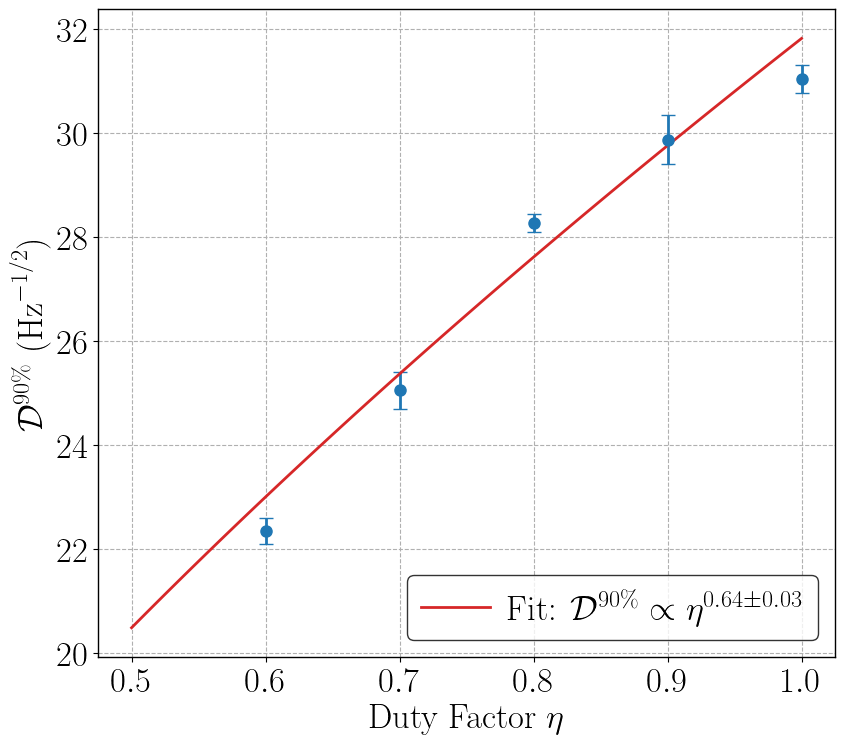

In [67]:
def binomialError(y, n):
    err =  np.sqrt(y*(1.-y)/n)
    err[err==0] = 1./n
    return err


D90 = []
D90_err = []

duty_factors = [1.0, 0.9, 0.8, 0.7, 0.6]


for duty_factor in duty_factors:
    pdet = data[f'pdet_df{duty_factor}']
    depth = data[f'depth_df{duty_factor}']
    
    print(pdet)
    print(depth)
    
    pdet = np.array(pdet)
    depth = np.array(depth)
    dpdet = binomialError(pdet, 1000)

    # Compute interpolation and error
    x, x_error = interpolation_error(0.9, depth, pdet, dpdet)
    D90.append(x)
    D90_err.append(x_error)
    
    
D90[0] = 31.04
D90 = np.array(D90)[::-1]
D90_Err = np.array(D90_err)[::-1]


duty_factors = np.array(duty_factors)[::-1]

# Define the power law function
from scipy.optimize import curve_fit
def power_law(x, k, a):
    return k * (x ** a)

# Normalize tobs


# Fit the power law with errors
popt, pcov = curve_fit(power_law, duty_factors, D90, p0=[1.3, 0.1], sigma=D90_err, absolute_sigma=True)
k, a = popt
k_err, a_err = np.sqrt(np.diag(pcov))

# Plot
fig, ax = plt.subplots(figsize=(9, 8))


ax.errorbar(duty_factors, D90, yerr=D90_err, fmt='o', color='tab:blue', 
            linewidth=2, markersize=8, capsize=5)

# Generate fitted curve
duty_factor_fit = np.linspace(0.5, 1, 100)
depth_fit = power_law(duty_factor_fit, k, a)
ax.plot(duty_factor_fit, depth_fit, linestyle='-', color='tab:red', 
        linewidth=2, label=f'Fit: $\\mathcal{{D}}^{{90\\%}} \\propto \eta^{{{a:.2f} \\pm {a_err:.2f}}}$')
# Axis labels and styling
ax.set_xlabel(r'$\mathrm{Duty\;Factor} \; \eta$')
ax.set_ylabel(r'$\mathcal{D}^{90\%}\; (\mathrm{Hz}^{-1/2})$')
#ax.set_xticks([5, 10, 15, 20])  # Ticks at 5, 10, 15, 20 days

ax.legend(loc=4, markerscale=2, handlelength=2, handletextpad=0.5, edgecolor='k')
ax.grid(True, which='major', linestyle='dashed')
#ax.set_ylim(20, 40)

# Save figure
plt.tight_layout()
fig.savefig('../result/plots/D90_duty_factor.pdf', dpi=300, bbox_inches='tight')